# TOPP-HATT

In some cases, we want to optimise an encoding without changing the underlying tree structure. For instance, we may want to use exactly the tree output from the [Bonsai Algorithm](https://ferrmion.readthedocs.io/en/latest/notebooks/bonsai.html).

`ferrmion` lets you do this with the `topphatt` algorithm.

This notebook demonstrates the benefits of the method, for simple examples of how to use it, please see the documentation on [encoding Hamiltonians with ferrmion.](https://ferrmion.readthedocs.io/en/latest/notebooks/encoding_hamiltonians.html).

For more details about the method itself, see our [preprint](https://arxiv.org/abs/2512.13580).

In [1]:
import ferrmion as fr
import numpy.random as rng
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path
from copy import deepcopy
import json
from ferrmion.visualise import symplectic_matshow
from nbutils import pauli_weights, get_naive_result, get_permuation_results, get_water_data, get_topphatt_result

We'll start as always by loading in some one and two electron integrals.

## How to use TOPP-HATT

The most straightforward way is to create a TernaryTree object, and then call `encode_topphatt` on it, passing in the Hamiltonian.

In [2]:
ones, twos, enuc = get_water_data()
fham = fr.molecular_hamiltonian(ones, twos, enuc)
tree = fr.BravyiKitaev(fham.n_modes)
pauli_ham = tree.encode(fham)
pauli_weights(pauli_ham)

(199925, 1813.9793432546799, 23328)

### Heuristics

There are a few different heuristics that can be applied during TOPP-HATT, which determine the order in which the tree is traversed and nodes are optimised.

- `min_weight`: the node with the smallest weight is optimised first. This is the default, and it also takes the longest to run as it can check multiple nodes during each iteration.
- `z_first`: the node at the z-most branch is optimised first.
- `x_first`: the node at the x-most branch is optimised first.
- `random`: the nodes are optimised in a random order. This can be used repeatedly to get a distribution of results.

In [3]:
print("Naive Bravyi-Kitaev:")
print(pauli_weights(fr.BravyiKitaev(fham.n_modes).encode(fham)))
print()

for heuristic in ["min_weight", "z_first", "x_first", "random"]:
    seeds = (
        [None] if heuristic != "random" else [rng.randint(0, 10000) for _ in range(10)]
    )

    print(f"Heuristic: {heuristic}")
    for s in seeds:
        pauli_ham = tree.encode(fham, heuristic=heuristic, seed=s)
        print(pauli_weights(pauli_ham))
    print()

Naive Bravyi-Kitaev:
(199925, 1813.9793432546799, 23328)

Heuristic: min_weight
(199925, 1813.9793432546799, 23328)

Heuristic: z_first
(196120, 1817.9672761330298, 23328)

Heuristic: x_first
(199925, 1813.9793432546799, 23328)

Heuristic: random
(205527, 1851.848382130617, 23328)
(203790, 1829.3865079014543, 23328)
(202946, 1824.1685621594893, 23328)
(200005, 1776.417121514982, 23328)
(207304, 1869.5548196660961, 23328)
(206873, 1886.9984476035825, 23328)
(203851, 1802.307704016663, 23328)
(204199, 1854.6972097402777, 23328)
(204999, 1872.0721668668045, 23328)
(199696, 1826.860932157147, 23328)



## Weight Reduction

Below we demonstrate the reduction in Pauli-weight and Coefficient-scaled Pauli-weight that can be achieved with TOPP-HATT.

In [4]:
def get_topp_hatt_results(
    tree: fr.TernaryTree, name, ones, twos, enuc, limit=1000, save=False
):
    fham = fr.molecular_hamiltonian(ones, twos, enuc)

    sdmeans_naive = get_naive_result(tree, fham)
    sdmeans = get_permuation_results(tree, fham, limit)

    sdmeans_topphatt = get_topphatt_result(deepcopy(tree), fham)

    color_set = {
        "jw": "tab:blue",
        "pe": "tab:orange",
        "bk": "tab:green",
        "jkmn": "tab:red",
        "bonsai": "tab:purple",
        "huffman": "tab:brown",
        "hatt": "tab:pink",
    }
    fig, ax = plt.subplots(layout="constrained")

    ax.scatter(
        sdmeans["unscaled"],
        sdmeans["scaled"],
        label=f"{limit} Random Permutations",
        marker=".",
        color="tab:grey",
        alpha=0.7,
    )
    ax.plot(
        sdmeans_naive["unscaled"],
        sdmeans_naive["scaled"],
        marker="D",
        color="tab:red",
        mec="k",
        markersize=8,
    )

    topphatt_heuristic_styles = {
        "min_weight": ("P", "tab:green"),
        "z_first": ("^", "tab:green"),
        "x_first": ("v", "tab:green"),
    }
    for heuristic, (marker, color) in topphatt_heuristic_styles.items():
        ax.plot(
            sdmeans_topphatt[heuristic]["unscaled"],
            sdmeans_topphatt[heuristic]["scaled"],
            marker=marker,
            linestyle="",
            color=color,
            mec="k",
            markersize=8,
        )
    ax.scatter(
        sdmeans_topphatt["random"]["unscaled"],
        sdmeans_topphatt["random"]["scaled"],
        marker="*",
        color="tab:green",
        edgecolor="k",
        s=80,
        label="TOPP-HATT random",
    )

    # where some data has already been plotted to ax
    handles, labels = plt.gca().get_legend_handles_labels()
    # manually define a new patch
    naive_legend = mlines.Line2D(
        [],
        [],
        label="Naive Enumeration",
        marker="D",
        linestyle="",
        color="tab:red",
        mec="k",
        markersize=8,
    )
    topphatt_min_weight_legend = mlines.Line2D(
        [],
        [],
        label="TOPP-HATT min_weight",
        marker="P",
        linestyle="",
        color="tab:green",
        mec="k",
        markersize=8,
    )
    topphatt_zfirst_legend = mlines.Line2D(
        [],
        [],
        label="TOPP-HATT z_first",
        marker="^",
        linestyle="",
        color="tab:green",
        mec="k",
        markersize=8,
    )
    topphatt_xfirst_legend = mlines.Line2D(
        [],
        [],
        label="TOPP-HATT x_first",
        marker="v",
        linestyle="",
        color="tab:green",
        mec="k",
        markersize=8,
    )

    data = {
        "random": sdmeans,
        "naive": sdmeans_naive,
        "topphatt": sdmeans_topphatt,
    }
    if save:
        with open(f"{name}.json", "w+") as f:
            json.dump(data, f)

    # handles is a list, so append manual patch
    handles.extend(
        [
            naive_legend,
            topphatt_min_weight_legend,
            topphatt_zfirst_legend,
            topphatt_xfirst_legend,
        ]
    )

    ax.set_xlabel("unscaled pauli-weight")
    ax.set_ylabel("coefficient scaled pauli-weight")
    ax.set_title(f"{name} Encodings of $H_2 O$:$6-31G$")
    fig.legend(handles=handles, loc="outside lower center", ncols=len(handles) // 2)
    fig.show()

# Standard Encodings

Getting Naive result...
Naive result: (285512, 2342.116727060445, 23328)
Getting 1000 random results...
Permutation Results
Running rust TOPP-HATT...
Getting rust TOPP-HATT result (heuristic=min_weight)...
TOPP-HATT min_weight result: (214156, 1480.8662101680088, 23328)
Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (214156, 1480.8662101680088, 23328)
Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (214156, 1480.8662101680088, 23328)
Getting 10 rust TOPP-HATT random results...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_16357/908125624.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


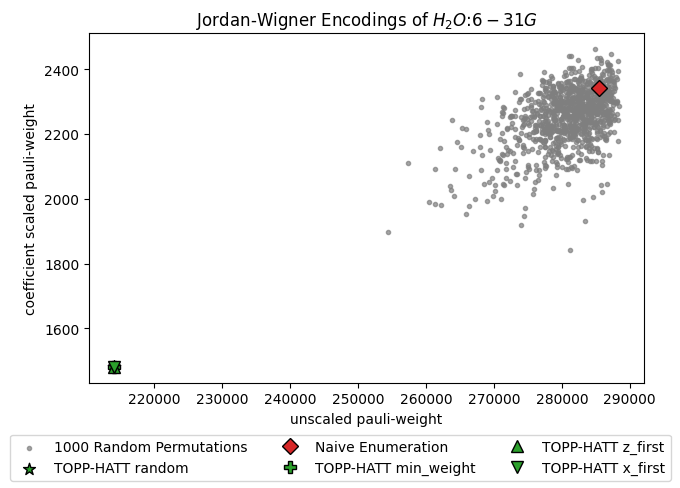

In [5]:
get_topp_hatt_results(fr.JordanWigner(ones.shape[0]), "Jordan-Wigner", ones, twos, enuc)

Getting Naive result...
Naive result: (287756, 2629.636652911664, 23328)
Getting 1000 random results...
Permutation Results
Running rust TOPP-HATT...
Getting rust TOPP-HATT result (heuristic=min_weight)...
TOPP-HATT min_weight result: (217334, 1784.0478644430164, 23328)
Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (217334, 1784.0478644430164, 23328)
Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (217334, 1784.0478644430166, 23328)
Getting 10 rust TOPP-HATT random results...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_16357/908125624.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


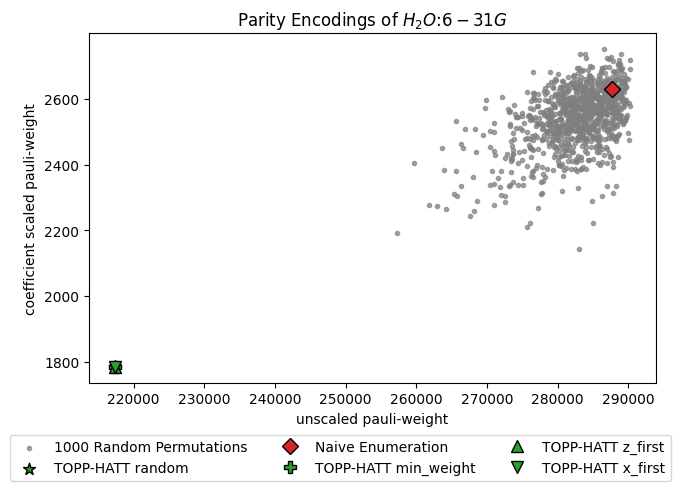

In [6]:
get_topp_hatt_results(fr.Parity(ones.shape[0]), "Parity", ones, twos, enuc)

Getting Naive result...
Naive result: (203787, 1997.5099410975386, 23328)
Getting 1000 random results...
Permutation Results
Running rust TOPP-HATT...
Getting rust TOPP-HATT result (heuristic=min_weight)...
TOPP-HATT min_weight result: (199925, 1813.9793432546799, 23328)
Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (196120, 1817.9672761330298, 23328)
Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (199925, 1813.9793432546799, 23328)
Getting 10 rust TOPP-HATT random results...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_16357/908125624.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


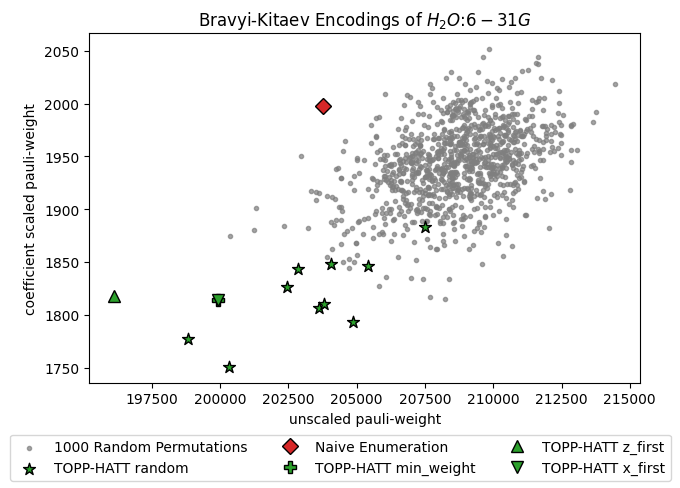

In [7]:
get_topp_hatt_results(fr.BravyiKitaev(ones.shape[0]), "Bravyi-Kitaev", ones, twos, enuc)

Getting Naive result...
Naive result: (193914, 1899.7020763850792, 23328)
Getting 1000 random results...
Permutation Results
Running rust TOPP-HATT...
Getting rust TOPP-HATT result (heuristic=min_weight)...
TOPP-HATT min_weight result: (184004, 1764.1926502308809, 23328)
Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (184962, 1700.7747138455043, 23328)
Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (181401, 1655.2210428745893, 23328)
Getting 10 rust TOPP-HATT random results...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_16357/908125624.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


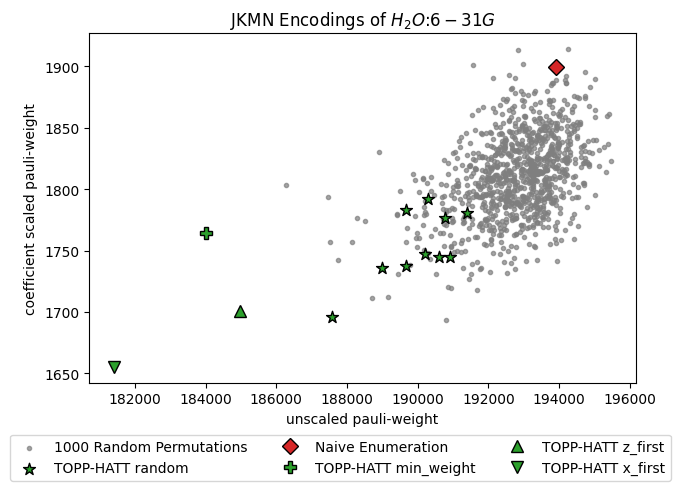

In [8]:
get_topp_hatt_results(fr.JKMN(ones.shape[0]), "JKMN", ones, twos, enuc)

# Hamiltonian Optimized Trees

TOPP-HATT can be applied to any ternary tree,  including those which are derived from other optimisation methods.

In [9]:
from ferrmion.optimize import huffman_ternary_tree

huffman_tree = huffman_ternary_tree(ones, twos)

Getting Naive result...
Naive result: (195812, 1935.9686248057617, 23328)
Getting 1000 random results...
Permutation Results
Running rust TOPP-HATT...
Getting rust TOPP-HATT result (heuristic=min_weight)...
TOPP-HATT min_weight result: (187616, 1716.9869796461226, 23328)
Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (189428, 1734.15095826791, 23328)
Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (185024, 1737.4638206214195, 23328)
Getting 10 rust TOPP-HATT random results...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_16357/908125624.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


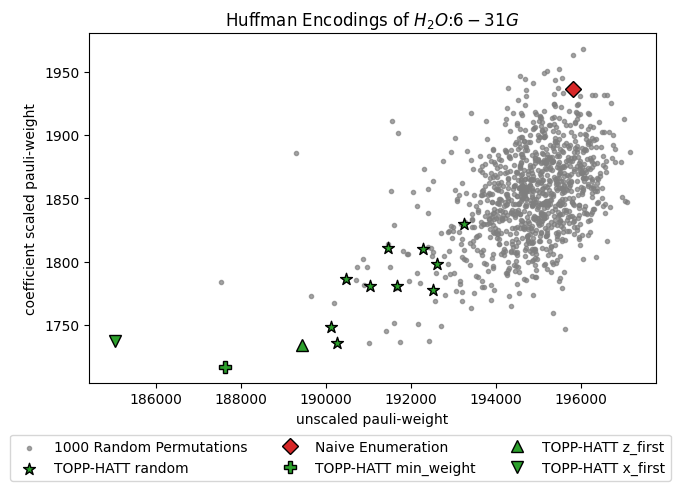

In [10]:
huffman_topphatt = get_topp_hatt_results(
    huffman_tree, name="Huffman", ones=ones, twos=twos, enuc=enuc
)

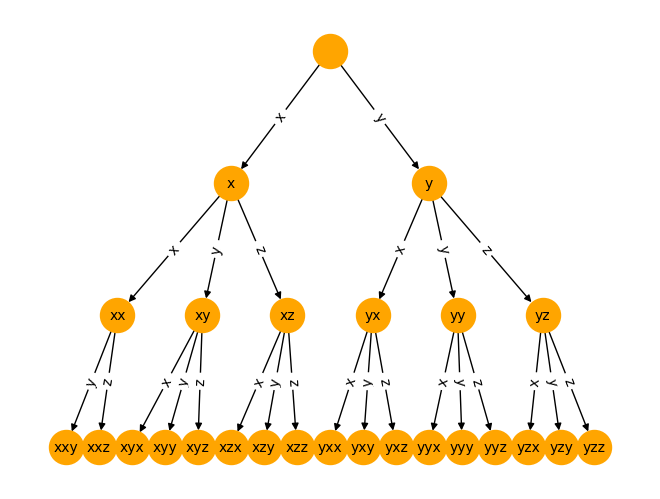

In [11]:
from ferrmion.visualise import draw_tt

draw_tt(huffman_tree)

For this one, we'll save time by using a pre-computed HATT tree. You can uncomment the line below to do it yourself, but it'll take a few minutes.

Getting HATT Tree...
Getting Naive result...
Naive result: (170142, 1529.341184391108, 23328)
Getting 1000 random results...
Permutation Results
Running rust TOPP-HATT...
Getting rust TOPP-HATT result (heuristic=min_weight)...
TOPP-HATT min_weight result: (189621, 1693.3269711308637, 23328)
Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (192082, 1710.174606091105, 23328)
Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (189578, 1689.352636507837, 23328)
Getting 10 rust TOPP-HATT random results...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_16357/908125624.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


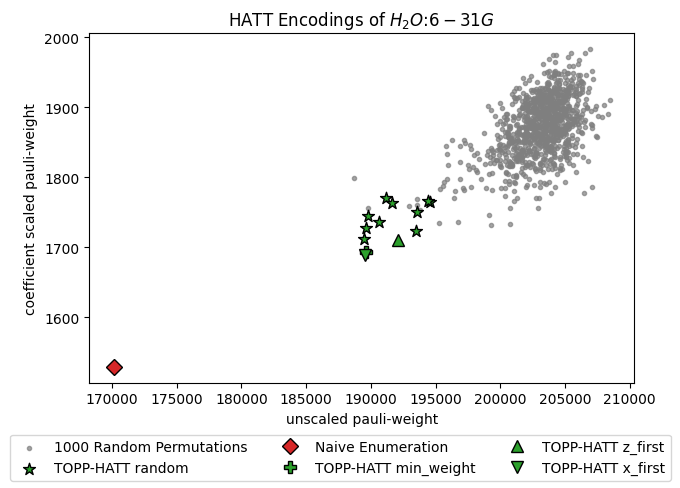

In [12]:
from ferrmion.optimize import hamiltonian_adaptive_ternary_tree

print("Getting HATT Tree...")
hatt_tree = hamiltonian_adaptive_ternary_tree(fham, fham.n_modes)

get_topp_hatt_results(hatt_tree, "HATT", ones=ones, twos=twos, enuc=enuc)

(None,
 {'': (0, 25),
  'x': (1, 17),
  'y': (2, 24),
  'z': (3, 22),
  'yx': (4, 23),
  'yy': (5, 14),
  'yz': (6, 15),
  'zx': (7, 16),
  'zy': (8, 21),
  'zz': (9, 4),
  'yxx': (10, 11),
  'yxy': (11, 12),
  'yxz': (12, 13),
  'zyx': (13, 20),
  'zyy': (14, 10),
  'zzz': (15, 3),
  'zyxx': (16, 19),
  'zyxy': (17, 8),
  'zyxz': (18, 9),
  'zzzx': (19, 1),
  'zzzy': (20, 2),
  'zzzz': (21, 0),
  'zyxxx': (22, 18),
  'zyxxy': (23, 6),
  'zyxxz': (24, 7),
  'zyxxxz': (25, 5)})

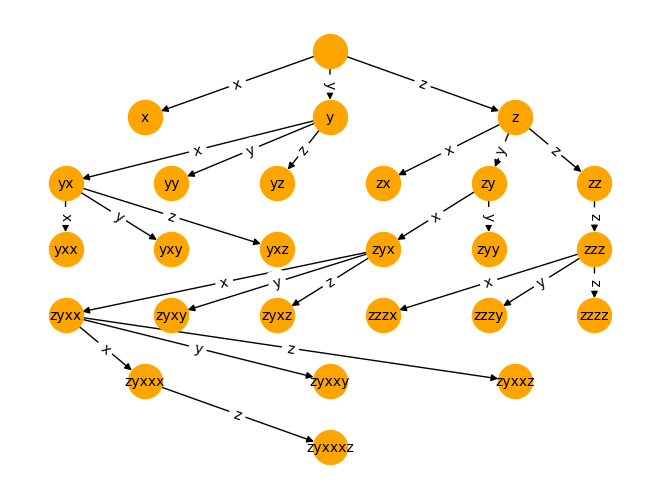

In [13]:
draw_tt(hatt_tree, type="spaced"), hatt_tree.enumeration_scheme

# Device Optimized Trees

In [14]:
import rustworkx as rx
from rustworkx import visualization as rxv
import matplotlib.pyplot as plt
import numpy as np


def heavy_hex_graph():
    graph = rx.PyGraph()
    graph.add_nodes_from(range(ones.shape[0]))
    graph.add_edges_from_no_data(
        [
            (a, b)
            for a, b in [
                (0, 1),
                (0, 2),
                (0, 3),
                (1, 4),
                (2, 5),
                (3, 6),
                (4, 7),
                (4, 8),
                (5, 9),
                (5, 10),
                (6, 11),
                (6, 12),
                (7, 13),
                (8, 14),
                (9, 15),
                (10, 16),
                (11, 17),
                (12, 18),
                (13, 19),
                (13, 20),
                (14, 21),
                (14, 22),
                (15, 23),
                (15, 24),
                (16, 25),
                (16, 26),
                (17, 27),
                (17, 28),
                (18, 29),
                (18, 30),
                (22, 31),
                (26, 32),
                (30, 33),
                (31, 34),
                (32, 35),
                (33, 36),
            ]
            if a < ones.shape[0] and b < ones.shape[1]
        ]
    )
    return graph

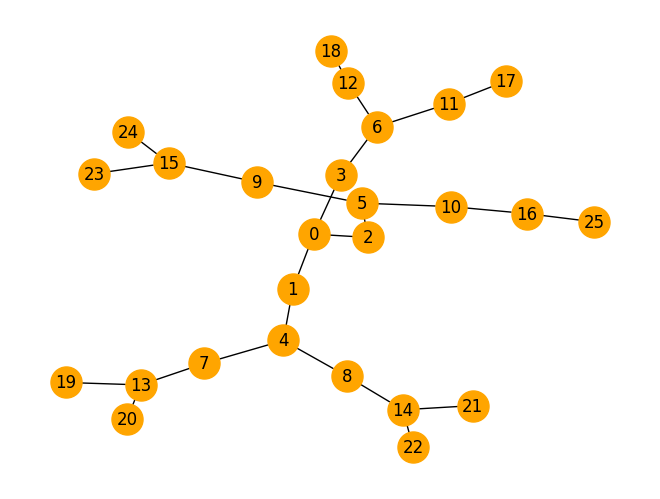

In [15]:
graph = heavy_hex_graph()
rxv.mpl_draw(graph, with_labels=True, node_color="orange", node_size=500)

Getting Naive result...
Naive result: (230900, 2144.0266986688484, 23328)
Getting 1000 random results...
Permutation Results
Running rust TOPP-HATT...
Getting rust TOPP-HATT result (heuristic=min_weight)...
TOPP-HATT min_weight result: (219713, 1886.7590141748842, 23328)
Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (212387, 1857.8143700186936, 23328)
Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (218203, 1901.4182023907993, 23328)
Getting 10 rust TOPP-HATT random results...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_16357/908125624.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


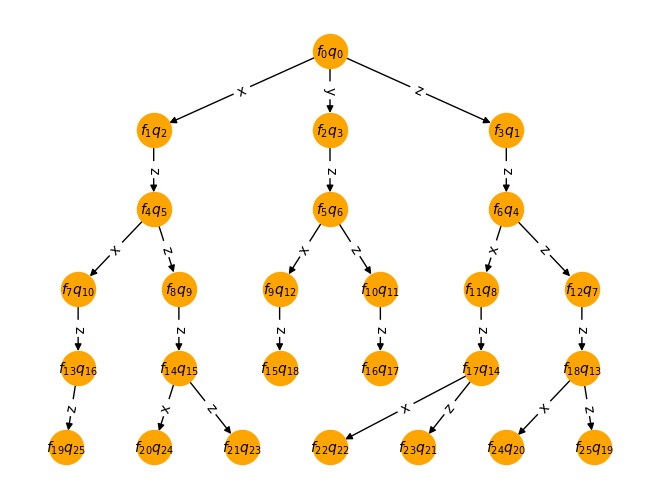

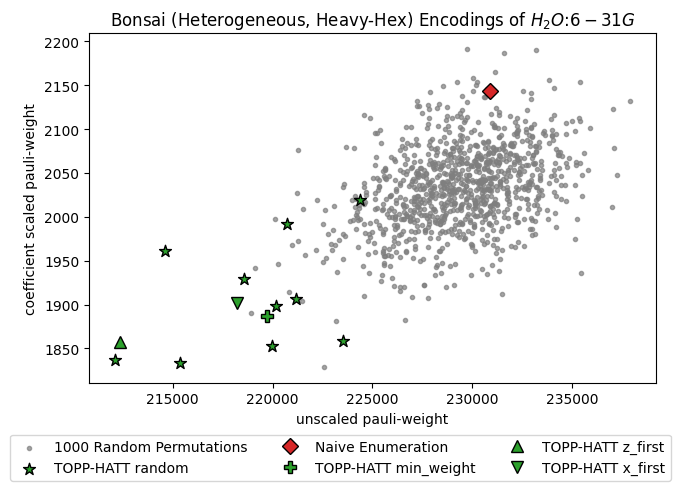

In [16]:
from ferrmion.visualise import draw_tt
from ferrmion.optimize import bonsai_algorithm

bonsai = bonsai_algorithm(graph=graph, homogenous=False)
draw_tt(bonsai, type="spaced", enumeration_scheme=bonsai.default_enumeration_scheme())
get_topp_hatt_results(
    bonsai, name="Bonsai (Heterogeneous, Heavy-Hex)", ones=ones, twos=twos, enuc=enuc
)

Getting Naive result...
Naive result: (235469, 2118.6399228920386, 23328)
Getting 1000 random results...
Permutation Results
Running rust TOPP-HATT...
Getting rust TOPP-HATT result (heuristic=min_weight)...
TOPP-HATT min_weight result: (217417, 1976.5438362779962, 23328)
Getting rust TOPP-HATT result (heuristic=z_first)...
TOPP-HATT z_first result: (215654, 1837.894002233677, 23328)
Getting rust TOPP-HATT result (heuristic=x_first)...
TOPP-HATT x_first result: (217876, 1997.9152897675933, 23328)
Getting 10 rust TOPP-HATT random results...


/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_16357/908125624.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


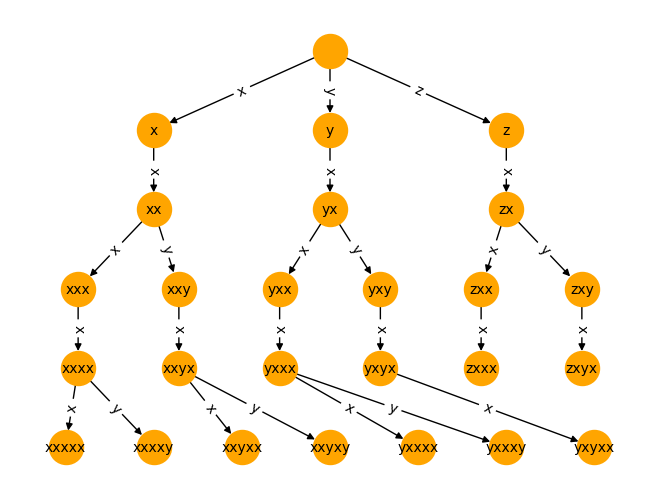

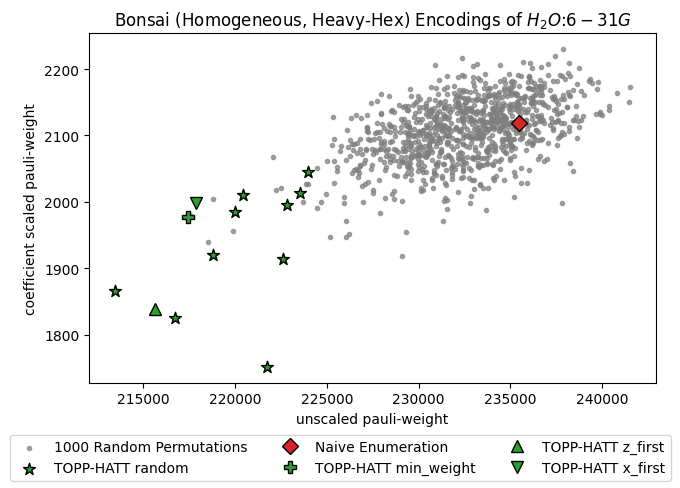

In [17]:
from ferrmion.optimize import bonsai_algorithm

bonsai = bonsai_algorithm(graph=graph, homogenous=True)
draw_tt(bonsai, type="spaced")
get_topp_hatt_results(
    bonsai, name="Bonsai (Homogeneous, Heavy-Hex)", ones=ones, twos=twos, enuc=enuc
)

# Use with Simulated Annealing

In general you should expect TOPP-HATT to be significantly faster than simulated annealing, so it can be used to find an initial state without affecting the runtime too much.

In [18]:
def compare_topphatt_annealing_runtime(tree, fham, n_seeds=5):
    import time

    runtimes = {
        "unweighted": [],
        "coefficient_weighted": [],
        "topphatt_random": [],
        "topphatt_min_weight": [],
    }
    weights = {
        "unweighted": [],
        "coefficient_weighted": [],
        "topphatt_random": [],
        "topphatt_min_weight": [],
    }
    for seed in range(n_seeds):
        iter_tree = deepcopy(tree)  # To ensure the same starting point for each run
        start_time = time.time()
        pham= iter_tree.encode_annealed(fham, coefficient_weighted=False, seed=seed)
        runtimes["unweighted"].append(time.time() - start_time)
        weights["unweighted"].append(pauli_weights(pham))

        iter_tree = deepcopy(tree)  # Reset tree for the next run
        start_time = time.time()
        pham= iter_tree.encode_annealed(fham, coefficient_weighted=True, seed=seed)
        runtimes["coefficient_weighted"].append(time.time() - start_time)
        weights["coefficient_weighted"].append(pauli_weights(pham))

        iter_tree = deepcopy(tree)
        start_time = time.time()
        pham= iter_tree.encode(fham, heuristic="random", seed=seed)
        runtimes["topphatt_random"].append(time.time() - start_time)
        weights["topphatt_random"].append(pauli_weights(pham))

        iter_tree = deepcopy(tree)
        start_time = time.time()
        pham = iter_tree.encode(fham, heuristic="min_weight", seed=seed)
        runtimes["topphatt_min_weight"].append(time.time() - start_time)
        weights["topphatt_min_weight"].append(pauli_weights(pham))

    print("Runtimes (seconds):")
    for key, values in runtimes.items():
        print(f"  {key}: {np.mean(values):.4f} ± {np.std(values):.4f}")

In [19]:
compare_topphatt_annealing_runtime(fr.BravyiKitaev(fham.n_modes), fham)

Runtimes (seconds):
  unweighted: 2.4287 ± 0.3345
  coefficient_weighted: 2.5749 ± 0.2951
  topphatt_random: 0.0333 ± 0.0005
  topphatt_min_weight: 0.0328 ± 0.0006
